# Flight Delay Analysis and Prediction
**Course:** PAML Spring 2026  
**Team:** Lin Wu, Yufan Peng, Xinrui Song, Xinyi Huang, Zhiying Huo  
**Data Source:** U.S. Bureau of Transportation Statistics (BTS) — 2025 Airline On-Time Performance

---
### Project Overview
This notebook covers the full ML pipeline:
1. Data loading & cleaning
2. Exploratory Data Analysis (EDA)
3. Airline performance evaluation
4. Random Forest classification (predict delay ≥15 min)
5. Linear regression (predict delay duration)
6. Streamlit deployment code

---
## ⚙️ Configuration — Fill This In Before Running

> **Only one variable needs to be changed before running the entire notebook:**  
> Set `data_directory` to the local folder where your BTS CSV dataset files are stored.  
> All subsequent cells will use this path automatically — no need to change it again.
>
> Download the dataset at: https://www.transtats.bts.gov/DL_SelectFields.aspx?gnoyr_VQ=FGK&QO_fu146_anzr=b0-gvzr

In [1]:
# ============================================================
# TODO: Change this to your local folder containing the CSV files
data_directory = '/Users/macbookpro/Downloads/Dataset'
# ============================================================
print(f"Data directory set to: {data_directory}")

Data directory set to: /Users/macbookpro/Downloads/Dataset


---
## Section 1 — Setup

In [2]:
import glob
import json
import pandas as pd
import numpy as np
import seaborn as sns
import altair as alt
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    mean_squared_error,
    r2_score,
)

# ── Column definitions ────────────────────────────────────────────────────────
REQUIRED_COLUMNS = [
    'YEAR', 'QUARTER', 'MONTH', 'FL_DATE', 'OP_UNIQUE_CARRIER',
    'ORIGIN', 'ORIGIN_CITY_NAME', 'ORIGIN_STATE_NM',
    'DEST',  'DEST_CITY_NAME',   'DEST_STATE_NM',
    'DEP_DELAY', 'DEP_DELAY_NEW', 'DEP_DEL15',
    'AIR_TIME', 'DISTANCE',
    'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY',
    'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY',
]

DELAY_COLUMNS = [
    'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY',
    'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY',
]

# Features used by both classification and regression models
# Includes route, airline, temporal, and operational delay features
CLASSIFICATION_FEATURES = [
    'MONTH', 'OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST',
    'DISTANCE', 'AIR_TIME',
    'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY',
    'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY',
]

REGRESSION_FEATURES = CLASSIFICATION_FEATURES.copy()

RANDOM_STATE  = 42
TEST_SIZE     = 0.2
SAMPLE_SIZE   = 200_000

---
## Section 2 — Helper Functions

In [3]:
def load_and_prepare_data(directory):
    """
    Load and combine BTS On-Time Reporting CSV files from a directory.
    Matches files like 202501T_ONTIME_REPORTING.csv; falls back to all CSVs.
    Only reads REQUIRED_COLUMNS to save memory. Validates column presence.
    Raises FileNotFoundError if no matching files are found.
    """
    # Try BTS-specific pattern first; fall back to all CSVs
    csv_files = sorted(glob.glob(f"{directory}/*ONTIME_REPORTING.csv"))
    if not csv_files:
        csv_files = sorted(glob.glob(f"{directory}/*.csv"))
    print(f"Files detected ({len(csv_files)}): {[f.split('/')[-1] for f in csv_files]}")
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in: {directory}")

    frames = []
    for f in csv_files:
        frame = pd.read_csv(f, usecols=lambda col: col in REQUIRED_COLUMNS)
        frame['source_file'] = f.split('/')[-1]
        frames.append(frame)

    combined_df = pd.concat(frames, ignore_index=True)

    missing = sorted(set(REQUIRED_COLUMNS) - set(combined_df.columns))
    if missing:
        print(f"⚠️  Columns not found in dataset (will be skipped): {missing}")

    print(f"Loaded {len(combined_df):,} rows from {len(csv_files)} file(s).")
    return combined_df

In [4]:
def clean_data(df, delay_columns):
    """
    Drop rows with NaN in key delay columns; clip negatives to 0;
    coerce numeric types; add distance_bucket feature.
    """
    df_cleaned = df.dropna(subset=delay_columns).copy()

    # Clip negative delay values to 0
    for col in ['CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY',
                'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY', 'DEP_DELAY_NEW']:
        if col in df_cleaned.columns:
            df_cleaned[col] = df_cleaned[col].clip(lower=0)

    # Coerce numeric types (guards against mixed-type CSVs)
    for col in ['MONTH', 'DISTANCE', 'AIR_TIME', 'DEP_DEL15', 'DEP_DELAY_NEW']:
        if col in df_cleaned.columns:
            df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

    df_cleaned = df_cleaned.dropna(
        subset=[c for c in ['MONTH', 'DISTANCE', 'AIR_TIME', 'DEP_DEL15', 'DEP_DELAY_NEW']
                if c in df_cleaned.columns]
    )

    if 'DEP_DEL15' in df_cleaned.columns:
        df_cleaned['DEP_DEL15'] = df_cleaned['DEP_DEL15'].astype(int)

    # Add distance bucket feature
    if 'DISTANCE' in df_cleaned.columns:
        df_cleaned['distance_bucket'] = pd.cut(
            df_cleaned['DISTANCE'],
            bins=[-1, 500, 1500, float('inf')],
            labels=['short_haul', 'medium_haul', 'long_haul']
        )

    return df_cleaned


def sample_data(df, sample_size=SAMPLE_SIZE, random_state=RANDOM_STATE):
    """Return a random sample of df if it exceeds sample_size rows."""
    if sample_size <= 0 or len(df) <= sample_size:
        return df
    print(f"Sampling {sample_size:,} rows from {len(df):,} total rows.")
    return df.sample(n=sample_size, random_state=random_state)

In [5]:
def build_preprocessor(features):
    """
    Build a ColumnTransformer that:
    - Imputes + scales numeric features
    - Imputes + one-hot-encodes categorical features
    """
    numeric_cols = [f for f in features if f in {
        'MONTH', 'DISTANCE', 'AIR_TIME',
        'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY',
        'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY',
    }]
    categorical_cols = [f for f in features if f not in numeric_cols]

    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])

    return ColumnTransformer(transformers=[
        ('num', numeric_pipeline,     numeric_cols),
        ('cat', categorical_pipeline, categorical_cols),
    ])

In [6]:
def overall_delay_analysis(df):
    """Return (avg_incl_neg, avg_excl_neg, early_departure_pct)."""
    avg_incl = df['DEP_DELAY'].mean()
    avg_excl = df['DEP_DELAY_NEW'].mean()
    early_pct = (df['DEP_DELAY'] < 0).sum() / len(df) * 100
    return avg_incl, avg_excl, early_pct


def analyze_grouped_counts(df):
    """
    Count flights by delay group.
    Uses DEP_DELAY_GROUP if available; otherwise bins DEP_DELAY_NEW into groups.
    """
    if 'DEP_DELAY_GROUP' in df.columns:
        return df['DEP_DELAY_GROUP'].value_counts().sort_index()

    # Derive delay group from DEP_DELAY (same BTS definition)
    bins   = [-float('inf'), -1, 0, 15, 30, 45, 60, 119, 179, 239, 299, 359, float('inf')]
    labels = [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 12]
    df = df.copy()
    df['DEP_DELAY_GROUP'] = pd.cut(df['DEP_DELAY'], bins=bins, labels=labels).astype(float)
    return df['DEP_DELAY_GROUP'].value_counts().sort_index()


def delay_factor_pie_charts(df, delay_columns):
    """
    Pie charts for overall delay factors and high-severity delays (≥61 min).
    High severity is defined as DEP_DELAY_NEW > 60 when DEP_DELAY_GROUP is absent.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    overall = df[delay_columns].sum()
    axes[0].pie(overall, labels=delay_columns, autopct='%1.1f%%', startangle=140)
    axes[0].set_title('Overall Delay Factors')

    # High-severity: DEP_DELAY_GROUP >= 4 (≥61 min) or DEP_DELAY_NEW > 60
    if 'DEP_DELAY_GROUP' in df.columns:
        high_mask = df['DEP_DELAY_GROUP'] >= 4
    else:
        high_mask = df['DEP_DELAY_NEW'] > 60

    high = df[high_mask][delay_columns].sum()
    axes[1].pie(high, labels=delay_columns, autopct='%1.1f%%', startangle=140)
    axes[1].set_title('High-Severity Delay Factors (>60 min)')

    plt.tight_layout()
    plt.savefig('delay_factor_pie_charts.png', dpi=150)
    plt.show()


def compare_short_long_haul(df, delay_columns):
    """Compare average delay factors for short-haul (≤500 mi) vs long-haul (>1500 mi)."""
    short_avg = df[df['DISTANCE'] <= 500][delay_columns].mean()
    long_avg  = df[df['DISTANCE'] >  1500][delay_columns].mean()
    return short_avg, long_avg


def top_cities_by_delay(df, delay_columns):
    """Return the top origin city (most total delay minutes) per delay reason."""
    top_cities = {}
    for reason in delay_columns:
        by_city = df.groupby('ORIGIN_CITY_NAME')[reason].sum()
        top_cities[reason] = {"City": by_city.idxmax(), "Total Delay (min)": by_city.max()}
    return pd.DataFrame(top_cities).T


def analyze_weather_delay_in_dallas_by_quarter(df):
    """Total WEATHER_DELAY in Dallas/Fort Worth by quarter."""
    if 'QUARTER' not in df.columns:
        print("'QUARTER' column missing.")
        return None
    dallas = df[df['ORIGIN_CITY_NAME'] == "Dallas/Fort Worth, TX"]
    return dallas.groupby('QUARTER')['WEATHER_DELAY'].sum()

In [7]:
def calculate_airline_delay_metrics(df):
    """Aggregate delay metrics per airline carrier."""
    perf = df.groupby('OP_UNIQUE_CARRIER').agg(
        DEP_DEL15        = ('DEP_DEL15',          'mean'),
        CARRIER_DELAY    = ('CARRIER_DELAY',       'sum'),
        WEATHER_DELAY    = ('WEATHER_DELAY',       'sum'),
        NAS_DELAY        = ('NAS_DELAY',           'sum'),
        SECURITY_DELAY   = ('SECURITY_DELAY',      'sum'),
        LATE_AIRCRAFT_DELAY = ('LATE_AIRCRAFT_DELAY', 'sum'),
        DEP_DELAY_NEW    = ('DEP_DELAY_NEW',       'mean'),
    ).reset_index()
    perf['Total_Flights']            = df.groupby('OP_UNIQUE_CARRIER').size().values
    perf['Delay_Ratio (%)']          = perf['DEP_DEL15'] * 100
    perf['Avg_Delay_Per_Flight (min)'] = perf['DEP_DELAY_NEW']
    perf['Total_Delay (min)']        = perf[DELAY_COLUMNS].sum(axis=1)
    perf['Delay_Contribution (%)']   = perf['Total_Delay (min)'] / perf['Total_Delay (min)'].sum() * 100
    return perf


def best_and_worst_airlines(airline_performance):
    """Return top-5 best and top-5 worst airlines by Delay_Ratio (%)."""
    best  = airline_performance.nsmallest(5, 'Delay_Ratio (%)')
    worst = airline_performance.nlargest(5,  'Delay_Ratio (%)')
    return best, worst


def airline_performance_by_factor(best, worst, delay_columns):
    """Extract delay factor columns for best and worst airlines."""
    cols = ['OP_UNIQUE_CARRIER'] + delay_columns
    return best[cols], worst[cols]


def visualize_airline_performance_metrics(airline_performance):
    """Bar plots for delay ratio and average delay; heatmap for delay correlations."""
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    sns.barplot(ax=axes[0],
                data=airline_performance.sort_values('Delay_Ratio (%)', ascending=False),
                x='OP_UNIQUE_CARRIER', y='Delay_Ratio (%)')
    axes[0].set_title('Delay Ratio (%) by Airline')
    axes[0].set_xlabel('Airline'); axes[0].set_ylabel('Delay Ratio (%)')
    axes[0].tick_params(axis='x', rotation=45)

    sns.barplot(ax=axes[1],
                data=airline_performance.sort_values('Avg_Delay_Per_Flight (min)', ascending=False),
                x='OP_UNIQUE_CARRIER', y='Avg_Delay_Per_Flight (min)')
    axes[1].set_title('Avg Delay Per Flight (min) by Airline')
    axes[1].set_xlabel('Airline'); axes[1].set_ylabel('Avg Delay (min)')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig('airline_delay_bar_charts.png', dpi=150)
    plt.show()

    plt.figure(figsize=(10, 8))
    delay_corr = airline_performance[DELAY_COLUMNS].corr()
    sns.heatmap(delay_corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Between Delay Types')
    plt.tight_layout()
    plt.savefig('correlation_heatmap_delay_types.png', dpi=150)
    plt.show()

In [8]:
def train_and_evaluate_classifier(df, best_airlines, worst_airlines):
    """
    Train and compare multiple classification models for predicting flight delays.
    Target: DEP_DEL15 (1 = delayed ≥15 min).

    Models:
    - Logistic Regression as baseline
    - Random Forest
    - Gradient Boosting
    - AdaBoost
    - Extra Trees

    Returns the best model pipeline based on F1 score.
    """
    model_df = sample_data(df)

    # Keep only available features and target
    needed = CLASSIFICATION_FEATURES + ['DEP_DEL15']
    available = [c for c in needed if c in model_df.columns]
    model_df = model_df[available].dropna(subset=['DEP_DEL15'])

    features_to_use = [c for c in CLASSIFICATION_FEATURES if c in model_df.columns]
    X = model_df[features_to_use]
    y = model_df['DEP_DEL15'].astype(int)

    stratify_arg = y if y.nunique() >= 2 else None
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=stratify_arg
    )

    # Define models for comparison
    model_specs = {
        "Logistic Regression": LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ),

        "Random Forest": RandomForestClassifier(
            n_estimators=150,
            max_depth=16,
            min_samples_leaf=5,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=RANDOM_STATE
        ),

        "AdaBoost": AdaBoostClassifier(
            n_estimators=100,
            learning_rate=0.1,
            random_state=RANDOM_STATE
        ),

        "Extra Trees": ExtraTreesClassifier(
            n_estimators=150,
            max_depth=16,
            min_samples_leaf=5,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    }

    trained_models = {}
    results = []

    for model_name, model in model_specs.items():
        print(f"\n=== {model_name} ===")

        pipe = Pipeline([
            ('preprocess', build_preprocessor(features_to_use)),
            ('model', model)
        ])

        pipe.fit(X_train, y_train)

        y_pred = pipe.predict(X_test)

        if hasattr(pipe.named_steps['model'], "predict_proba"):
            y_prob = pipe.predict_proba(X_test)[:, 1]
            roc_auc = roc_auc_score(y_test, y_prob)
        else:
            roc_auc = np.nan

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        print(classification_report(y_test, y_pred, zero_division=0))
        print(f"Accuracy : {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall   : {rec:.4f}")
        print(f"F1       : {f1:.4f}")
        print(f"ROC-AUC  : {roc_auc:.4f}")

        trained_models[model_name] = pipe

        results.append({
            "Model": model_name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1,
            "ROC-AUC": roc_auc
        })

    # Create comparison table
    comparison_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)

    print("\n=== Model Comparison Summary ===")
    display(comparison_df)

    # Save comparison results
    comparison_df.to_csv("classification_model_comparison.csv", index=False)

    with open('classification_metrics.json', 'w') as fp:
        json.dump(comparison_df.to_dict(orient='records'), fp, indent=2)

    print("\nSaved: classification_model_comparison.csv")
    print("Saved: classification_metrics.json")

    # Plot F1 comparison
    plt.figure(figsize=(10, 6))
    sns.barplot(data=comparison_df, x="Model", y="F1")
    plt.title("Classification Model Comparison by F1 Score")
    plt.xlabel("Model")
    plt.ylabel("F1 Score")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig("classification_model_comparison_f1.png", dpi=150)
    plt.show()

    # Plot ROC-AUC comparison
    plt.figure(figsize=(10, 6))
    sns.barplot(data=comparison_df, x="Model", y="ROC-AUC")
    plt.title("Classification Model Comparison by ROC-AUC")
    plt.xlabel("Model")
    plt.ylabel("ROC-AUC")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig("classification_model_comparison_roc_auc.png", dpi=150)
    plt.show()

    # Select best model based on F1 score
    best_model_name = comparison_df.iloc[0]["Model"]
    best_model = trained_models[best_model_name]

    print(f"\nBest model based on F1 Score: {best_model_name}")

    # Confusion matrix for best model
    best_pred = best_model.predict(X_test)

    plt.figure(figsize=(6, 5))
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, best_pred),
        display_labels=['On-Time', 'Delayed']
    ).plot(colorbar=False)
    plt.title(f'Confusion Matrix — Best Model: {best_model_name}')
    plt.tight_layout()
    plt.savefig('best_model_confusion_matrix.png', dpi=150)
    plt.show()

    # Per-airline delay likelihood using the best model
    print(f"\nAverage Delay Likelihood by Airline ({best_model_name}):")
    for label, group in [('Best 5', best_airlines), ('Worst 5', worst_airlines)]:
        print(f"  — {label} airlines —")
        for airline in group['OP_UNIQUE_CARRIER']:
            data = df[df['OP_UNIQUE_CARRIER'] == airline][features_to_use].dropna()
            if not data.empty:
                prob = best_model.predict_proba(data)[:, 1].mean()
                print(f"    {airline}: {prob:.2%}")

    return best_model


def random_forest_regression_analysis(df, target='DEP_DELAY_NEW'):
    """
    Train a Random Forest Regressor to predict departure delay duration.
    Only trains on actually-delayed flights (DEP_DELAY_NEW > 0).
    Uses the same full feature set with Pipeline preprocessing.
    Reports RMSE; saves metrics to JSON.
    Returns the trained pipeline.
    """
    print("\n=== Regression: Random Forest Regressor (delayed flights only) ===")

    features_to_use = [c for c in REGRESSION_FEATURES if c in df.columns]
    reg_df = df[df[target] > 0].copy() if target in df.columns else df.copy()
    reg_df = reg_df[features_to_use + [target]].dropna()

    reg_df = sample_data(reg_df)

    X = reg_df[features_to_use]
    y = reg_df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    rf_reg_pipe = Pipeline([
        ('preprocess', build_preprocessor(features_to_use)),
        ('model', RandomForestRegressor(
            n_estimators=150, max_depth=18, min_samples_leaf=5,
            random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ])
    rf_reg_pipe.fit(X_train, y_train)
    y_pred = rf_reg_pipe.predict(X_test)

    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    print(f"RMSE                : {rmse:.2f} minutes")
    print(f"Mean actual delay   : {y_test.mean():.2f} minutes")
    print(f"Mean predicted delay: {y_pred.mean():.2f} minutes")

    # Scatter: actual vs predicted (sample 2000 points for readability)
    idx = np.random.default_rng(RANDOM_STATE).choice(len(y_test), min(2000, len(y_test)), replace=False)
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test.iloc[idx], y_pred[idx], alpha=0.4, edgecolor='k', s=20)
    lim = max(y_test.max(), y_pred.max())
    plt.plot([0, lim], [0, lim], 'r--', label='Perfect fit')
    plt.title("Random Forest Regressor — Actual vs Predicted Delay")
    plt.xlabel("Actual Delay (min)")
    plt.ylabel("Predicted Delay (min)")
    plt.legend()
    plt.tight_layout()
    plt.savefig('regression_actual_vs_predicted.png', dpi=150)
    plt.show()

    # Save metrics
    with open('regression_metrics.json', 'w') as fp:
        json.dump({'random_forest_regressor': {
            'rmse': rmse,
            'mean_actual_delay':    float(y_test.mean()),
            'mean_predicted_delay': float(y_pred.mean()),
        }}, fp, indent=2)
    print("Saved: regression_metrics.json")

    return rf_reg_pipe

---
## Section 3 — Load Data

In [9]:
df = load_and_prepare_data(data_directory)

Files detected (12): ['202501T_ONTIME_REPORTING.csv', '202502T_ONTIME_REPORTING.csv', '202503T_ONTIME_REPORTING.csv', '202504T_ONTIME_REPORTING.csv', '202505T_ONTIME_REPORTING.csv', '202506T_ONTIME_REPORTING.csv', '202507T_ONTIME_REPORTING.csv', '202508T_ONTIME_REPORTING.csv', '202509T_ONTIME_REPORTING.csv', '202510T_ONTIME_REPORTING.csv', '202511T_ONTIME_REPORTING.csv', '202512T_ONTIME_REPORTING.csv']
Loaded 7,001,619 rows from 12 file(s).


---
## Section 4 — Exploratory Data Analysis (EDA)

In [10]:
print("Shape:", df.shape)
print("\nAll columns:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

Shape: (7001619, 22)

All columns:
   1. YEAR
   2. QUARTER
   3. MONTH
   4. FL_DATE
   5. OP_UNIQUE_CARRIER
   6. ORIGIN
   7. ORIGIN_CITY_NAME
   8. ORIGIN_STATE_NM
   9. DEST
  10. DEST_CITY_NAME
  11. DEST_STATE_NM
  12. DEP_DELAY
  13. DEP_DELAY_NEW
  14. DEP_DEL15
  15. AIR_TIME
  16. DISTANCE
  17. CARRIER_DELAY
  18. WEATHER_DELAY
  19. NAS_DELAY
  20. SECURITY_DELAY
  21. LATE_AIRCRAFT_DELAY
  22. source_file


In [11]:
print("\nDataset info:")
df.info()

print("\nMissing values (top 15):")
print(df.isnull().sum().sort_values(ascending=False).head(15))


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7001619 entries, 0 to 7001618
Data columns (total 22 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   QUARTER              int64  
 2   MONTH                int64  
 3   FL_DATE              object 
 4   OP_UNIQUE_CARRIER    object 
 5   ORIGIN               object 
 6   ORIGIN_CITY_NAME     object 
 7   ORIGIN_STATE_NM      object 
 8   DEST                 object 
 9   DEST_CITY_NAME       object 
 10  DEST_STATE_NM        object 
 11  DEP_DELAY            float64
 12  DEP_DELAY_NEW        float64
 13  DEP_DEL15            float64
 14  AIR_TIME             float64
 15  DISTANCE             float64
 16  CARRIER_DELAY        float64
 17  WEATHER_DELAY        float64
 18  NAS_DELAY            float64
 19  SECURITY_DELAY       float64
 20  LATE_AIRCRAFT_DELAY  float64
 21  source_file          object 
dtypes: float64(10), int64(3), object(9)
memory usage: 1

In [12]:
df.head()

,YEAR,QUARTER,MONTH,FL_DATE,OP_UNIQUE_CARRIER,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_NM,DEST,DEST_CITY_NAME,...,DEP_DELAY_NEW,DEP_DEL15,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,source_file
0,2025,1,1,1/1/2025 12:00:00 AM,AA,JFK,"New York, NY",New York,LAX,"Los Angeles, CA",...,0.0,0.0,345.0,2475.0,NaN,NaN,NaN,NaN,NaN,202501T_ONTIME_REPORTING.csv
1,2025,1,1,1/1/2025 12:00:00 AM,AA,LAX,"Los Angeles, CA",California,JFK,"New York, NY",...,0.0,0.0,274.0,2475.0,NaN,NaN,NaN,NaN,NaN,202501T_ONTIME_REPORTING.csv
2,2025,1,1,1/1/2025 12:00:00 AM,AA,MSN,"Madison, WI",Wisconsin,CLT,"Charlotte, NC",...,36.0,1.0,91.0,708.0,20.0,0.0,0.0,0.0,0.0,202501T_ONTIME_REPORTING.csv
3,2025,1,1,1/1/2025 12:00:00 AM,AA,PHL,"Philadelphia, PA",Pennsylvania,LAS,"Las Vegas, NV",...,1.0,0.0,306.0,2176.0,NaN,NaN,NaN,NaN,NaN,202501T_ONTIME_REPORTING.csv
4,2025,1,1,1/1/2025 12:00:00 AM,AA,ORD,"Chicago, IL",Illinois,PHX,"Phoenix, AZ",...,0.0,0.0,212.0,1440.0,0.0,0.0,44.0,0.0,0.0,202501T_ONTIME_REPORTING.csv


In [13]:
df.describe()

,YEAR,QUARTER,MONTH,DEP_DELAY,DEP_DELAY_NEW,DEP_DEL15,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
count,7001619.0,7.001619e+06,7.001619e+06,6.903028e+06,6.903028e+06,6.903028e+06,6.879484e+06,7.001619e+06,1.534638e+06,1.534638e+06,1.534638e+06,1.534638e+06,1.534638e+06
mean,2025.0,2.523899e+00,6.571156e+00,1.355640e+01,1.704553e+01,2.175602e-01,1.168443e+02,8.444474e+02,2.367097e+01,4.632176e+00,1.595410e+01,9.956876e-02,2.858197e+01
std,0.0,1.105366e+00,3.394144e+00,5.753804e+01,5.635458e+01,4.125867e-01,7.125513e+01,6.019752e+02,7.474651e+01,3.481617e+01,3.641466e+01,3.336252e+00,6.176802e+01
min,2025.0,1.000000e+00,1.000000e+00,-1.150000e+02,0.000000e+00,0.000000e+00,7.000000e+00,3.100000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2025.0,2.000000e+00,4.000000e+00,-6.000000e+00,0.000000e+00,0.000000e+00,6.400000e+01,4.030000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2025.0,3.000000e+00,7.000000e+00,-2.000000e+00,0.000000e+00,0.000000e+00,1.000000e+02,6.920000e+02,2.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00
75%,2025.0,4.000000e+00,1.000000e+01,1.000000e+01,1.000000e+01,0.000000e+00,1.470000e+02,1.080000e+03,2.000000e+01,0.000000e+00,1.900000e+01,0.000000e+00,3.300000e+01
max,2025.0,4.000000e+00,1.200000e+01,4.352000e+03,4.352000e+03,1.000000e+00,9.530000e+02,5.095000e+03,4.336000e+03,2.394000e+03,1.706000e+03,9.900000e+02,2.425000e+03


---
## Section 5 — Data Cleaning

In [14]:
delay_cols_for_cleaning = [
    'DEP_DELAY', 'DEP_DELAY_NEW', 'DEP_DEL15',
    'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY',
    'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY'
]

df_cleaned = clean_data(df.copy(), delay_cols_for_cleaning)

print(f"Original shape : {df.shape}")
print(f"Cleaned shape  : {df_cleaned.shape}")
print("\nMissing values after cleaning (target columns):")
print(df_cleaned[delay_cols_for_cleaning].isnull().sum())
df_cleaned.tail()

Original shape : (7001619, 22)
Cleaned shape  : (1534638, 23)

Missing values after cleaning (target columns):
DEP_DELAY              0
DEP_DELAY_NEW          0
DEP_DEL15              0
CARRIER_DELAY          0
WEATHER_DELAY          0
NAS_DELAY              0
SECURITY_DELAY         0
LATE_AIRCRAFT_DELAY    0
dtype: int64


,YEAR,QUARTER,MONTH,FL_DATE,OP_UNIQUE_CARRIER,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_NM,DEST,DEST_CITY_NAME,...,DEP_DEL15,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,source_file,distance_bucket
7001592,2025,4,12,12/31/2025 12:00:00 AM,YX,IND,"Indianapolis, IN",Indiana,JFK,"New York, NY",...,0,91.0,665.0,0.0,0.0,7.0,0.0,14.0,202512T_ONTIME_REPORTING.csv,medium_haul
7001603,2025,4,12,12/31/2025 12:00:00 AM,YX,DTW,"Detroit, MI",Michigan,SDF,"Louisville, KY",...,1,65.0,306.0,3.0,0.0,34.0,0.0,64.0,202512T_ONTIME_REPORTING.csv,short_haul
7001604,2025,4,12,12/31/2025 12:00:00 AM,YX,MCO,"Orlando, FL",Florida,IND,"Indianapolis, IN",...,1,133.0,829.0,16.0,0.0,0.0,0.0,0.0,202512T_ONTIME_REPORTING.csv,medium_haul
7001607,2025,4,12,12/31/2025 12:00:00 AM,YX,LGA,"New York, NY",New York,BUF,"Buffalo, NY",...,1,55.0,292.0,13.0,0.0,0.0,0.0,28.0,202512T_ONTIME_REPORTING.csv,short_haul
7001609,2025,4,12,12/31/2025 12:00:00 AM,YX,SYR,"Syracuse, NY",New York,JFK,"New York, NY",...,1,46.0,209.0,0.0,0.0,0.0,0.0,84.0,202512T_ONTIME_REPORTING.csv,short_haul


---
## Section 6 — Overall Delay Analysis

In [15]:
avg_incl, avg_excl, early_pct = overall_delay_analysis(df_cleaned)
print(f"Avg departure delay (incl. early departures) : {avg_incl:.2f} min")
print(f"Avg departure delay (excl. early departures) : {avg_excl:.2f} min")
print(f"Percentage of early departures               : {early_pct:.2f}%")

Avg departure delay (incl. early departures) : 67.84 min
Avg departure delay (excl. early departures) : 68.35 min
Percentage of early departures               : 10.15%


Flight counts by DEP_DELAY_GROUP:
DEP_DELAY_GROUP
-2.0     155719
-1.0      18828
 0.0     160235
 1.0     246115
 2.0     242125
 3.0     169547
 4.0     316350
 5.0     115861
 6.0      50340
 7.0      23322
 8.0      11466
 12.0     24730
Name: count, dtype: int64


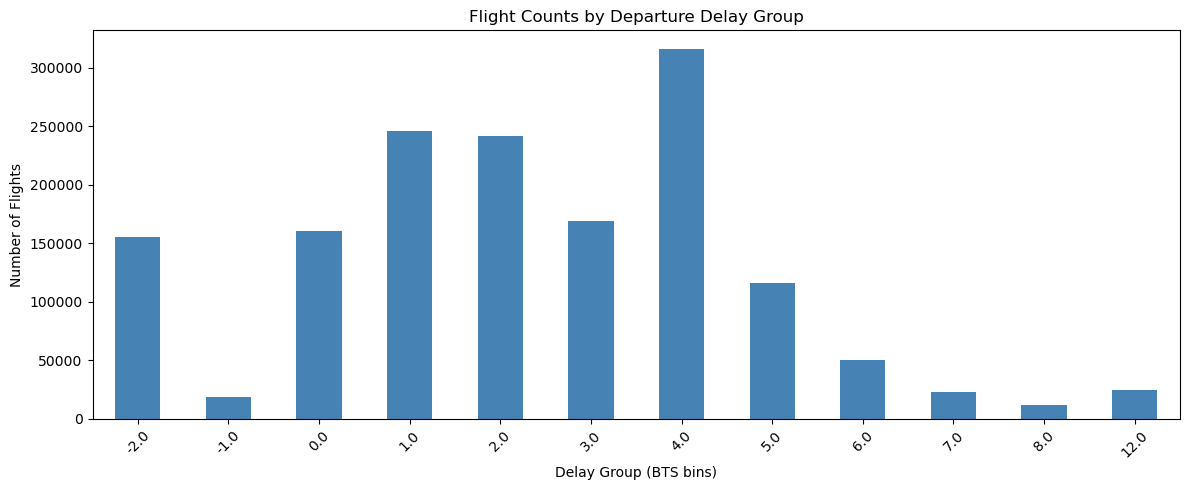

In [16]:
delay_group_counts = analyze_grouped_counts(df_cleaned)
print("Flight counts by DEP_DELAY_GROUP:")
print(delay_group_counts)

plt.figure(figsize=(12, 5))
delay_group_counts.plot(kind='bar', color='steelblue')
plt.title('Flight Counts by Departure Delay Group')
plt.xlabel('Delay Group (BTS bins)')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('flight_counts_by_delay_group.png', dpi=150)
plt.show()

---
## Section 7 — Delay Factor Distribution

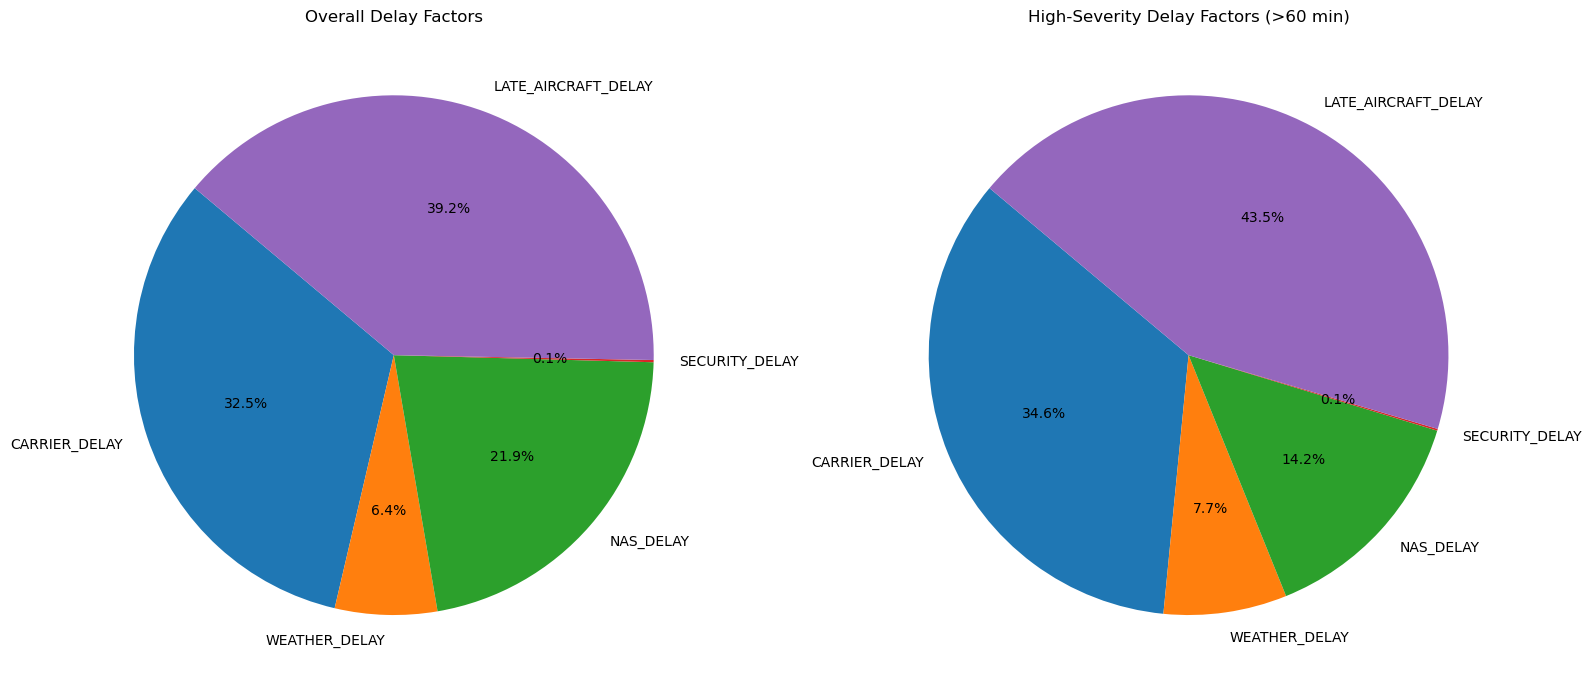

In [17]:
delay_factor_pie_charts(df_cleaned, DELAY_COLUMNS)

---
## Section 8 — Short-Haul vs Long-Haul Comparison

Short-haul (≤500 mi) avg delays:
 CARRIER_DELAY          24.265861
WEATHER_DELAY           5.955818
NAS_DELAY              14.561068
SECURITY_DELAY          0.080934
LATE_AIRCRAFT_DELAY    29.043786
dtype: float64

Long-haul (>1500 mi) avg delays:
 CARRIER_DELAY          25.052118
WEATHER_DELAY           2.706638
NAS_DELAY              16.327954
SECURITY_DELAY          0.129195
LATE_AIRCRAFT_DELAY    24.241827
dtype: float64


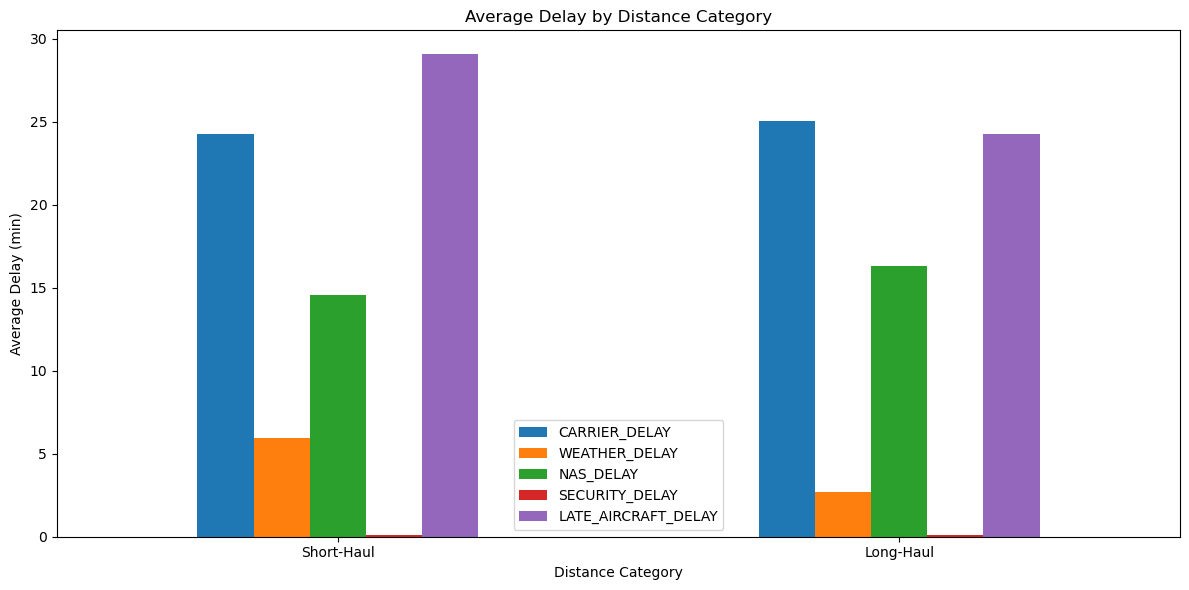

In [18]:
short_avg, long_avg = compare_short_long_haul(df_cleaned, DELAY_COLUMNS)
print("Short-haul (≤500 mi) avg delays:\n", short_avg)
print("\nLong-haul (>1500 mi) avg delays:\n", long_avg)

comparison_df = pd.DataFrame({'Short-Haul': short_avg, 'Long-Haul': long_avg}).T
comparison_df.plot(kind='bar', figsize=(12, 6))
plt.title('Average Delay by Distance Category')
plt.ylabel('Average Delay (min)')
plt.xlabel('Distance Category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('short_vs_long_haul_delays.png', dpi=150)
plt.show()

---
## Section 9 — Top Cities by Delay Reason

In [19]:
top_cities_df = top_cities_by_delay(df_cleaned, DELAY_COLUMNS)
print("Top origin city for each delay reason:")
top_cities_df

Top origin city for each delay reason:


,City,Total Delay (min)
CARRIER_DELAY,"Chicago, IL",2258494.0
WEATHER_DELAY,"Chicago, IL",591589.0
NAS_DELAY,"Chicago, IL",1560750.0
SECURITY_DELAY,"Orlando, FL",8127.0
LATE_AIRCRAFT_DELAY,"Chicago, IL",2972354.0


---
## Section 10 — Weather Delay in Dallas by Quarter

QUARTER
1    124943.0
2    221737.0
3    146326.0
4     86587.0
Name: WEATHER_DELAY, dtype: float64


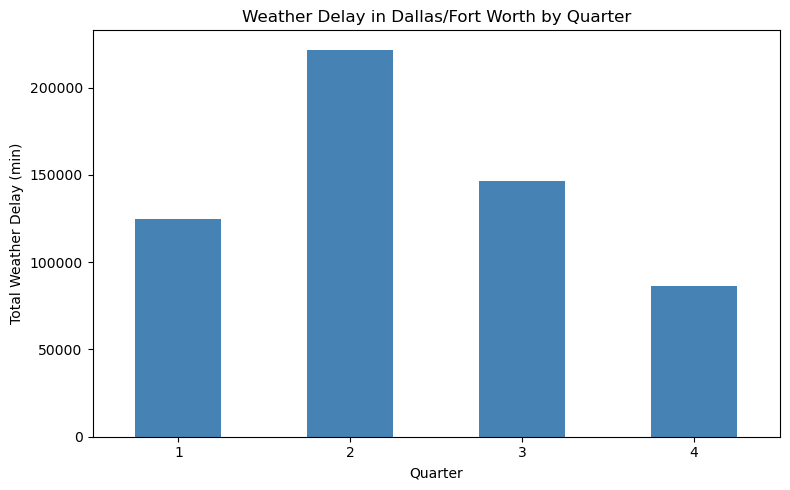

In [20]:
dallas_weather = analyze_weather_delay_in_dallas_by_quarter(df_cleaned)
if dallas_weather is not None:
    print(dallas_weather)
    plt.figure(figsize=(8, 5))
    dallas_weather.plot(kind='bar', color='steelblue')
    plt.title('Weather Delay in Dallas/Fort Worth by Quarter')
    plt.xlabel('Quarter')
    plt.ylabel('Total Weather Delay (min)')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig('dallas_weather_delay_by_quarter.png', dpi=150)
    plt.show()

---
## Section 11 — Airline Performance Metrics

In [21]:
airline_performance_df = calculate_airline_delay_metrics(df_cleaned)
airline_performance_df

,OP_UNIQUE_CARRIER,DEP_DEL15,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,DEP_DELAY_NEW,Total_Flights,Delay_Ratio (%),Avg_Delay_Per_Flight (min),Total_Delay (min),Delay_Contribution (%)
0,AA,0.806808,6665139.0,1211424.0,3175129.0,24866.0,9332142.0,79.007482,244989,80.680765,79.007482,20408700.0,18.232696
1,AS,0.704010,795569.0,100207.0,820059.0,13840.0,1141042.0,44.625637,55887,70.400988,44.625637,2870717.0,2.564637
2,B6,0.795372,1225977.0,121217.0,1271929.0,7148.0,1887779.0,71.484348,59288,79.537174,71.484348,4514050.0,4.032756
3,DL,0.789468,6285303.0,741254.0,3118947.0,9165.0,4529947.0,69.111491,200402,78.946817,69.111491,14684616.0,13.118922
4,F9,0.804933,1271174.0,133427.0,869032.0,0.0,2301817.0,80.080717,54202,80.493340,80.080717,4575450.0,4.087609
5,G4,0.820279,816412.0,324920.0,499061.0,10933.0,1117818.0,79.079098,32428,82.027877,79.079098,2769144.0,2.473894
6,HA,0.725383,448352.0,23221.0,8797.0,3439.0,242879.0,48.530489,13710,72.538293,48.530489,726688.0,0.649208
7,MQ,0.737329,790124.0,459193.0,933117.0,4431.0,1698868.0,54.251792,61400,73.732899,54.251792,3885733.0,3.471431
8,NK,0.810315,766079.0,90125.0,1412721.0,9406.0,765608.0,71.180816,40931,81.031492,71.180816,3043939.0,2.719390
9,OH,0.814528,1702297.0,441148.0,793949.0,8249.0,2987623.0,86.228874,65158,81.452776,86.228874,5933266.0,5.300653


In [22]:
best_airlines, worst_airlines = best_and_worst_airlines(airline_performance_df)

print("Top 5 Best Airlines (lowest delay ratio):")
print(best_airlines[['OP_UNIQUE_CARRIER', 'Delay_Ratio (%)', 'Avg_Delay_Per_Flight (min)']].to_string(index=False))

print("\nTop 5 Worst Airlines (highest delay ratio):")
print(worst_airlines[['OP_UNIQUE_CARRIER', 'Delay_Ratio (%)', 'Avg_Delay_Per_Flight (min)']].to_string(index=False))

Top 5 Best Airlines (lowest delay ratio):
OP_UNIQUE_CARRIER  Delay_Ratio (%)  Avg_Delay_Per_Flight (min)
               AS        70.400988                   44.625637
               YX        71.678473                   61.203209
               UA        72.112075                   65.554471
               HA        72.538293                   48.530489
               MQ        73.732899                   54.251792

Top 5 Worst Airlines (highest delay ratio):
OP_UNIQUE_CARRIER  Delay_Ratio (%)  Avg_Delay_Per_Flight (min)
               WN        86.225579                   56.832308
               G4        82.027877                   79.079098
               OH        81.452776                   86.228874
               NK        81.031492                   71.180816
               AA        80.680765                   79.007482


In [23]:
best_factors, worst_factors = airline_performance_by_factor(best_airlines, worst_airlines, DELAY_COLUMNS)

with pd.option_context('display.max_columns', None, 'display.expand_frame_repr', False):
    print("Best 5 Airlines — Delay Factor Breakdown:")
    print(best_factors.to_string(index=False))
    print("\nWorst 5 Airlines — Delay Factor Breakdown:")
    print(worst_factors.to_string(index=False))

Best 5 Airlines — Delay Factor Breakdown:
OP_UNIQUE_CARRIER  CARRIER_DELAY  WEATHER_DELAY  NAS_DELAY  SECURITY_DELAY  LATE_AIRCRAFT_DELAY
               AS       795569.0       100207.0   820059.0         13840.0            1141042.0
               YX      1199923.0       296125.0  1774298.0          3286.0            1889711.0
               UA      3139179.0       632202.0  4001508.0           719.0            4472603.0
               HA       448352.0        23221.0     8797.0          3439.0             242879.0
               MQ       790124.0       459193.0   933117.0          4431.0            1698868.0

Worst 5 Airlines — Delay Factor Breakdown:
OP_UNIQUE_CARRIER  CARRIER_DELAY  WEATHER_DELAY  NAS_DELAY  SECURITY_DELAY  LATE_AIRCRAFT_DELAY
               WN      4402140.0       495601.0  3242617.0         39461.0            8600998.0
               G4       816412.0       324920.0   499061.0         10933.0            1117818.0
               OH      1702297.0       441148.0   

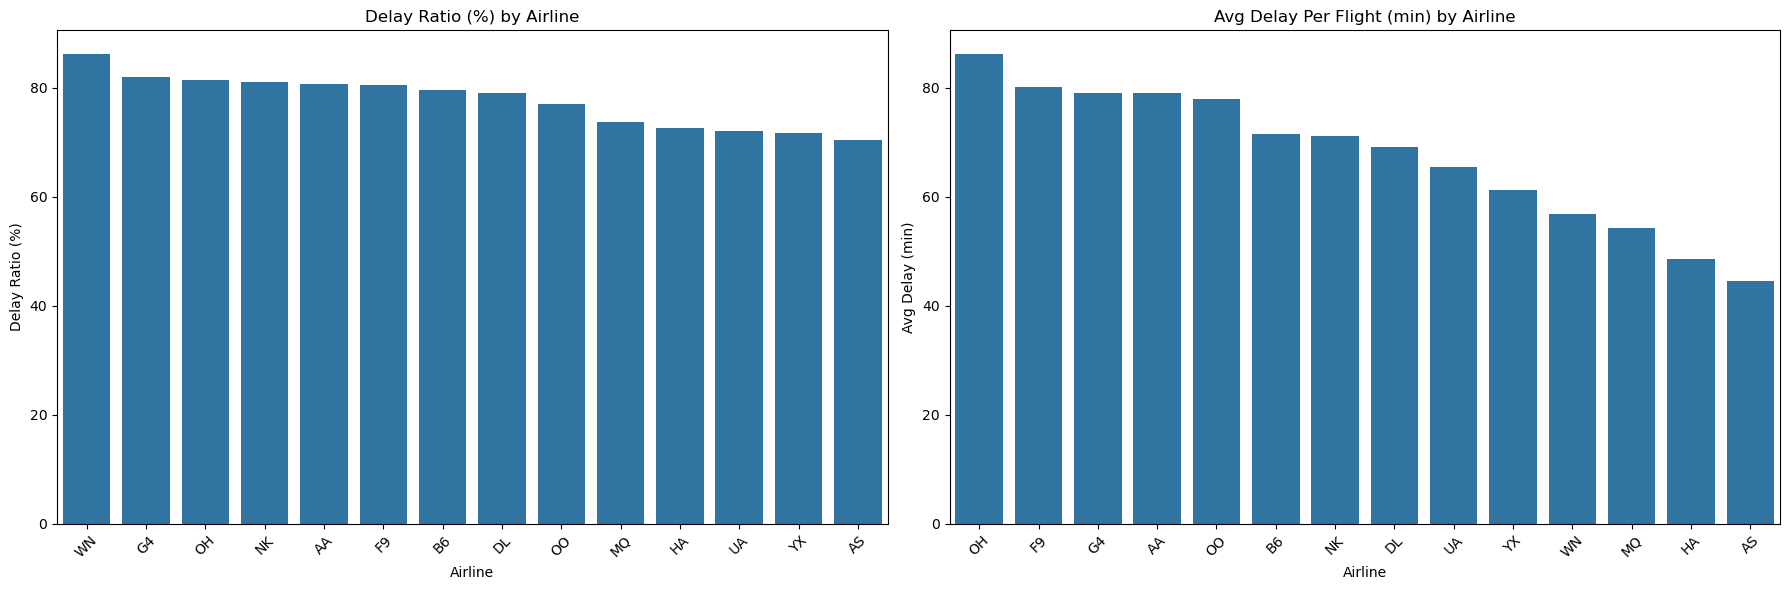

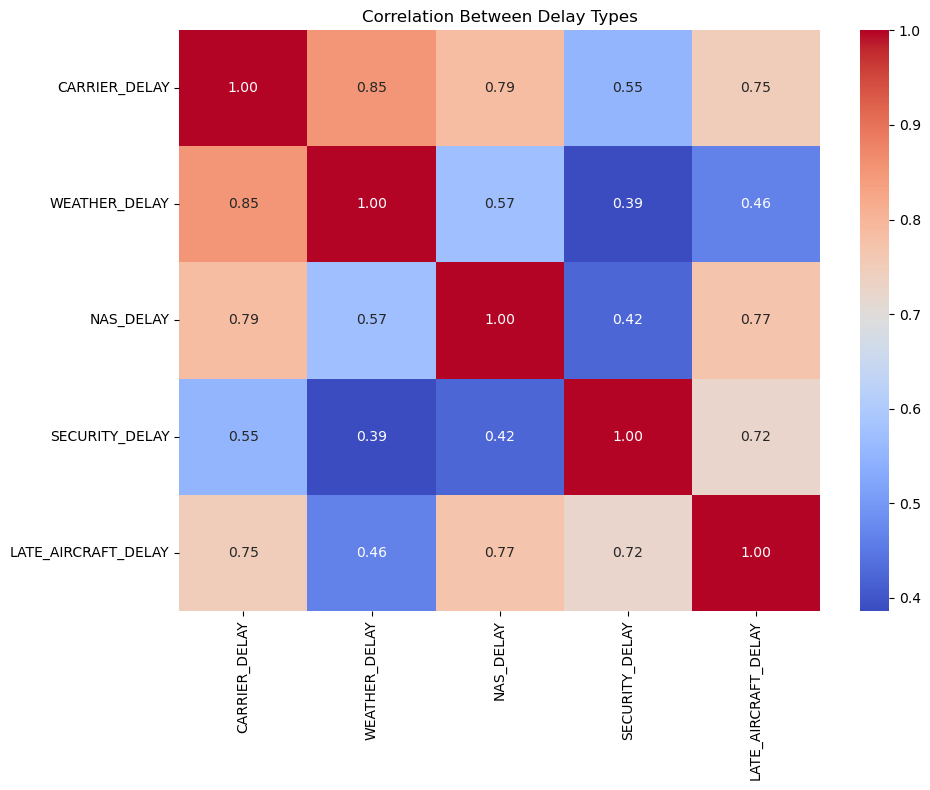

In [24]:
visualize_airline_performance_metrics(airline_performance_df)

In [25]:
airline_performance_df.to_csv('airline_performance_metrics.csv', index=False)
print("Saved: airline_performance_metrics.csv")

Saved: airline_performance_metrics.csv


---
## Section 12 — Classification Model (Random Forest)
**Task:** Predict whether a flight will be delayed ≥15 minutes (`DEP_DEL15`).  
**Baseline:** Logistic Regression | **Main model:** Random Forest  
**Features:** 5 delay-cause variables (carrier, weather, NAS, security, late aircraft)  
**Split:** 80% train / 20% test

Sampling 200,000 rows from 1,534,638 total rows.

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.66      0.94      0.77      8342
           1       0.98      0.87      0.92     31658

    accuracy                           0.89     40000
   macro avg       0.82      0.90      0.85     40000
weighted avg       0.91      0.89      0.89     40000

Accuracy : 0.8851
Precision: 0.9811
Recall   : 0.8716
F1       : 0.9231
ROC-AUC  : 0.9636

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.94      0.11      0.20      8342
           1       0.81      1.00      0.89     31658

    accuracy                           0.81     40000
   macro avg       0.88      0.55      0.55     40000
weighted avg       0.84      0.81      0.75     40000

Accuracy : 0.8129
Precision: 0.8097
Recall   : 0.9982
F1       : 0.8941
ROC-AUC  : 0.9622

=== Gradient Boosting ===
              precision    recall  f1-

/Users/macbookpro/anaconda3/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.82      0.84      0.83      8342
           1       0.96      0.95      0.95     31658

    accuracy                           0.93     40000
   macro avg       0.89      0.90      0.89     40000
weighted avg       0.93      0.93      0.93     40000

Accuracy : 0.9279
Precision: 0.9573
Recall   : 0.9514
F1       : 0.9543
ROC-AUC  : 0.9653

=== Extra Trees ===
              precision    recall  f1-score   support

           0       0.36      0.67      0.47      8342
           1       0.89      0.69      0.78     31658

    accuracy                           0.69     40000
   macro avg       0.63      0.68      0.62     40000
weighted avg       0.78      0.69      0.71     40000

Accuracy : 0.6866
Precision: 0.8890
Recall   : 0.6902
F1       : 0.7771
ROC-AUC  : 0.7392

=== Model Comparison Summary ===


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,Gradient Boosting,0.938325,0.960295,0.961842,0.961068,0.983021
3,AdaBoost,0.927900,0.957282,0.951355,0.954309,0.965276
0,Logistic Regression,0.885075,0.981084,0.871596,0.923105,0.963616
1,Random Forest,0.812925,0.809706,0.998231,0.894139,0.962178
4,Extra Trees,0.686575,0.889002,0.690157,0.777061,0.739191



Saved: classification_model_comparison.csv
Saved: classification_metrics.json


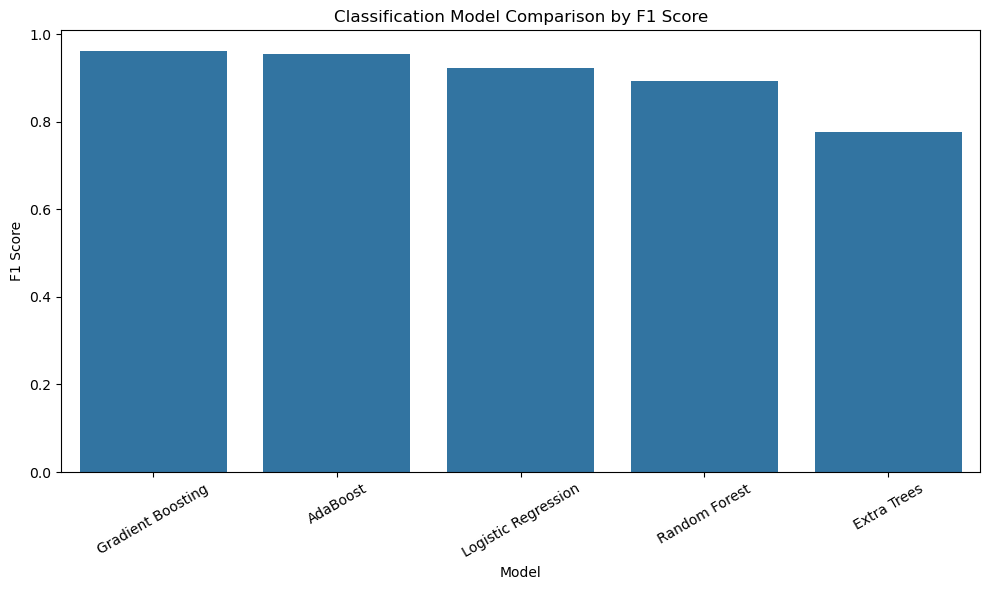

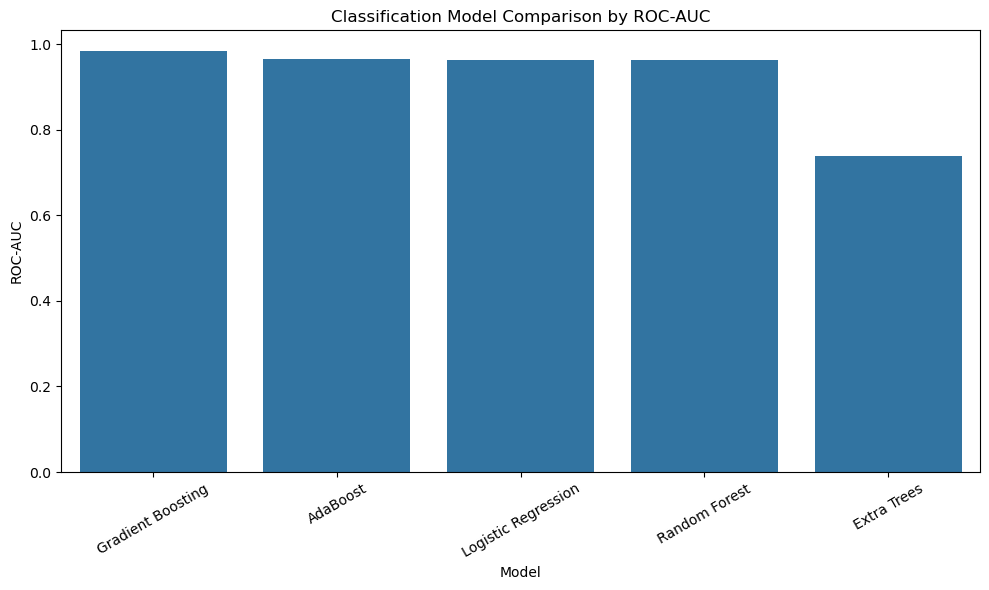


Best model based on F1 Score: Gradient Boosting


<Figure size 600x500 with 0 Axes>

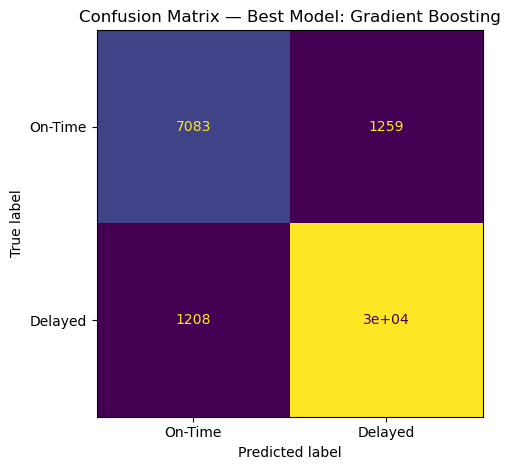


Average Delay Likelihood by Airline (Gradient Boosting):
  — Best 5 airlines —
    AS: 70.72%
    YX: 73.14%
    UA: 71.69%
    HA: 78.16%
    MQ: 76.10%
  — Worst 5 airlines —
    WN: 85.50%
    G4: 81.07%
    OH: 83.10%
    NK: 77.45%
    AA: 81.24%


In [26]:
best_classifier_model = train_and_evaluate_classifier(
    df_cleaned,
    best_airlines,
    worst_airlines
)

---
## Section 13 — Regression Model (Linear Regression)
**Task:** Predict delay duration in minutes (`DEP_DELAY_NEW`).  
**Metric:** RMSE and R²


=== Regression: Random Forest Regressor (delayed flights only) ===
Sampling 200,000 rows from 1,360,091 total rows.
RMSE                : 13.04 minutes
Mean actual delay   : 77.69 minutes
Mean predicted delay: 77.74 minutes


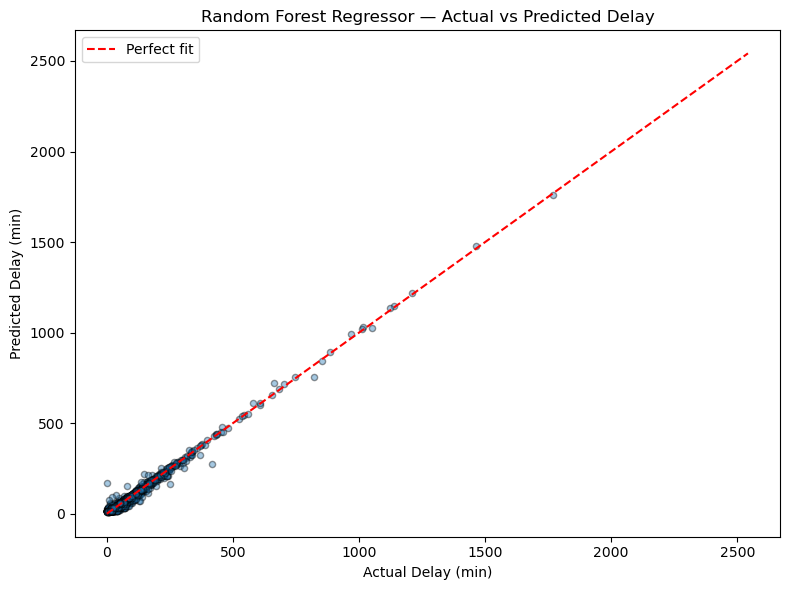

Saved: regression_metrics.json


In [27]:
rf_reg_model = random_forest_regression_analysis(df_cleaned)

---
## Section 14 — Streamlit App

The cell below contains the **complete Streamlit application code**.  
Run the next cell to write `app.py`, then follow the instructions to launch it.

### How to run

#### Option A — Google Colab (using ngrok)
```bash
# 1. Install dependencies
!pip install streamlit pyngrok -q

# 2. Write the app file (run the cell below)

# 3. Start Streamlit in the background and expose via ngrok
!streamlit run app.py &
from pyngrok import ngrok
public_url = ngrok.connect(8501)
print("Streamlit URL:", public_url)
```

#### Option B — Local machine
```bash
pip install streamlit scikit-learn pandas matplotlib seaborn
streamlit run app.py
# Opens automatically at http://localhost:8501
```

### Input fields
| Field | Type |
|---|---|
| Departure Airport | Dropdown |
| Arrival Airport | Dropdown |
| Travel Month | Dropdown |
| Airline | Dropdown |

### Outputs
- Recommended airline (lowest predicted delay risk)
- Delay probability for each airline (classification)
- Expected delay duration in minutes (regression)
- Bar chart comparison across airlines
- Delay cause breakdown (donut chart)

In [42]:
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import altair as alt
import matplotlib.patches as mpatches
import glob
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# ── Page config ───────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="Flight Delay Predictor",
    page_icon="✈️",
    layout="wide"
)

DELAY_COLS = ["CARRIER_DELAY", "WEATHER_DELAY", "NAS_DELAY",
              "SECURITY_DELAY", "LATE_AIRCRAFT_DELAY"]
DELAY_LABELS = ["Carrier", "Weather", "NAS", "Security", "Late Aircraft"]

# ── Data loading (cached) ─────────────────────────────────────────────────────
@st.cache_data
def load_data(directory="Dataset"):
    files = glob.glob(f"{directory}/*.csv")
    if not files:
        st.error(f"No CSV files found in '{directory}'.")
        st.stop()
    df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    clean_cols = ["DEP_DELAY", "DEP_DELAY_NEW", "DEP_DEL15"] + DELAY_COLS
    df = df.dropna(subset=clean_cols).copy()
    for c in DELAY_COLS:
        df[c] = df[c].clip(lower=0)
    return df

# ── Model training (cached) ───────────────────────────────────────────────────
@st.cache_resource
def train_models(df):
    X = df[DELAY_COLS].fillna(0)
    y_cls = df["DEP_DEL15"].astype(int)
    y_reg = df["DEP_DELAY_NEW"]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y_cls, test_size=0.2, random_state=42)
    rfc = RandomForestClassifier(n_estimators=100, max_depth=10,
                                  random_state=42, n_jobs=-1)
    rfc.fit(X_tr, y_tr)
    lr = LinearRegression().fit(X, y_reg)
    return rfc, lr

# ── Airline metrics (cached) ──────────────────────────────────────────────────
@st.cache_data
def compute_airline_metrics(df):
    perf = df.groupby("OP_UNIQUE_CARRIER").agg(
        Delay_Ratio        = ("DEP_DEL15",     "mean"),
        Avg_Delay          = ("DEP_DELAY_NEW", "mean"),
        CARRIER_DELAY      = ("CARRIER_DELAY",      "mean"),
        WEATHER_DELAY      = ("WEATHER_DELAY",      "mean"),
        NAS_DELAY          = ("NAS_DELAY",          "mean"),
        SECURITY_DELAY     = ("SECURITY_DELAY",     "mean"),
        LATE_AIRCRAFT_DELAY= ("LATE_AIRCRAFT_DELAY","mean"),
    ).reset_index()
    perf["Delay_Ratio (%)"] = perf["Delay_Ratio"] * 100
    q1 = perf["Delay_Ratio (%)"].quantile(0.33)
    q2 = perf["Delay_Ratio (%)"].quantile(0.66)

    perf["Reliability"] = perf["Delay_Ratio (%)"].apply(
        lambda x: "⭐⭐⭐ Lower Risk" if x <= q1
                else ("⭐⭐ Medium Risk" if x <= q2 else "⭐ Higher Risk")
    )
    return perf

# ── Load everything ───────────────────────────────────────────────────────────
df = load_data()
rfc, lr_model = train_models(df)
airline_metrics = compute_airline_metrics(df)

# ── Sidebar ───────────────────────────────────────────────────────────────────
st.sidebar.title("✈️ Flight Delay Predictor")
st.sidebar.markdown("Powered by **ML Classification** + **Random Forest Regression**")
st.sidebar.markdown("---")

origin_cities  = sorted(df["ORIGIN_CITY_NAME"].dropna().unique())
dest_cities    = sorted(df["DEST_CITY_NAME"].dropna().unique())
airlines       = sorted(df["OP_UNIQUE_CARRIER"].dropna().unique())
months         = list(range(1, 13))
month_names    = ["Jan","Feb","Mar","Apr","May","Jun",
                  "Jul","Aug","Sep","Oct","Nov","Dec"]

origin  = st.sidebar.selectbox("Departure City", origin_cities)
dest    = st.sidebar.selectbox("Arrival City",   dest_cities)
month   = st.sidebar.selectbox(
    "Travel Month",
    months,
    format_func=lambda m: month_names[m-1]
)

risk_threshold = st.sidebar.slider(
    "Delay Risk Threshold (%)",
    min_value=10,
    max_value=90,
    value=50,
    step=5,
    help="Flights with predicted delay probability above this threshold will be marked as High Risk."
)
st.sidebar.caption(

    "Lower threshold = more conservative. Higher threshold = more flexible."

)

predict_btn = st.sidebar.button("🔍 Predict & Compare", width="stretch")

# ── Main page ─────────────────────────────────────────────────────────────────
st.title("✈️ U.S. Flight Delay Prediction & Airline Recommendation")
st.markdown(
    "Enter your trip details on the left, then click **Predict & Compare** "
    "to get real-time delay predictions and airline recommendations."
)

if predict_btn:
    # Filter historical data for the chosen route + month
    route_df = df[
        (df["ORIGIN_CITY_NAME"] == origin) &
        (df["DEST_CITY_NAME"]   == dest)   &
        (df["MONTH"]            == month)
    ]

    if route_df.empty:
        st.warning(
            "No historical data found for this route/month combination. "
            "Showing predictions based on overall airline averages."
        )
        route_df = df[df["MONTH"] == month]

    results = []
    for carrier in airlines:
        carrier_df = route_df[route_df["OP_UNIQUE_CARRIER"] == carrier]
        if carrier_df.empty:
            carrier_df = df[df["OP_UNIQUE_CARRIER"] == carrier]
        if carrier_df.empty:
            continue
        X_pred = carrier_df[DELAY_COLS].fillna(0)
        delay_prob    = rfc.predict_proba(X_pred)[:, 1].mean()
        expected_delay = lr_model.predict(X_pred).mean()
        avg_causes    = X_pred.mean().tolist()
        results.append({
            "Airline": carrier,
            "Delay Probability (%)": round(delay_prob * 100, 1),
            "Expected Delay (min)": round(max(expected_delay, 0), 1),
            **{label: round(val, 1) for label, val in zip(DELAY_LABELS, avg_causes)}
        })

    if not results:
        st.error("Could not generate predictions. Please try a different route.")
        st.stop()

    results_df = pd.DataFrame(results).sort_values("Delay Probability (%)", ascending=True)
    results_df["Risk Level"] = np.where(
        results_df["Delay Probability (%)"] >= risk_threshold,
        "High Risk",
        "Acceptable Risk"
    )
    # ── Best airline recommendation ───────────────────────────────────────────
    acceptable_df = results_df[results_df["Risk Level"] == "Acceptable Risk"]

    if not acceptable_df.empty:
        best = acceptable_df.iloc[0]
    else:
        best = results_df.iloc[0]
        st.warning(
            "All available airlines are above your selected risk threshold. "
            "Showing the lowest-risk option instead."
        )

    st.markdown("---")
    st.subheader("🏆 Lowest-Risk Airline Option")

    # Smaller unified metric cards
    risk_color = "#2ecc71" if best["Risk Level"] == "Acceptable Risk" else "#ff4b4b"

    metric_html = f"""
    <div style="display:grid; grid-template-columns:repeat(4, 1fr); gap:18px; margin-top:10px;">

    <div style="padding:18px 20px; border-radius:16px; background-color:rgba(255,255,255,0.04); border:1px solid rgba(255,255,255,0.10);">
        <div style="font-size:15px; color:#A0A4AA; font-weight:600;">Airline</div>
        <div style="font-size:28px; color:white; font-weight:700; margin-top:8px;">{best["Airline"]}</div>
    </div>

    <div style="padding:18px 20px; border-radius:16px; background-color:rgba(255,255,255,0.04); border:1px solid rgba(255,255,255,0.10);">
        <div style="font-size:15px; color:#A0A4AA; font-weight:600;">Delay Probability</div>
        <div style="font-size:28px; color:white; font-weight:700; margin-top:8px;">{best["Delay Probability (%)"]:.1f}%</div>
    </div>

    <div style="padding:18px 20px; border-radius:16px; background-color:rgba(255,255,255,0.04); border:1px solid rgba(255,255,255,0.10);">
        <div style="font-size:15px; color:#A0A4AA; font-weight:600;">Expected Delay</div>
        <div style="font-size:28px; color:white; font-weight:700; margin-top:8px;">{best["Expected Delay (min)"]:.1f} min</div>
    </div>

    <div style="padding:18px 20px; border-radius:16px; background-color:rgba(255,255,255,0.04); border:1px solid rgba(255,255,255,0.10);">
        <div style="font-size:15px; color:#A0A4AA; font-weight:600;">Risk Level</div>
        <div style="display:inline-block; font-size:18px; color:{risk_color}; font-weight:700; margin-top:10px; padding:5px 10px; border-radius:999px; background-color:{risk_color}22; border:1px solid {risk_color}; white-space:nowrap;">
        {best["Risk Level"]}
        </div>
    </div>

    </div>
    """

    st.markdown(metric_html, unsafe_allow_html=True)

    # ── Airline comparison table ──────────────────────────────────────────────
    st.markdown("---")
    st.subheader("📊 Airline Comparison")
    display_df = results_df[
        ["Airline", "Delay Probability (%)", "Expected Delay (min)", "Risk Level"]
    ].copy()
    display_df = display_df.merge(
        airline_metrics[["OP_UNIQUE_CARRIER", "Reliability"]],
        left_on="Airline", right_on="OP_UNIQUE_CARRIER", how="left"
    ).drop(columns="OP_UNIQUE_CARRIER")
    st.dataframe(display_df.reset_index(drop=True), width="stretch")

    # ── Airline comparison charts ───────────────────────────────────────────────
    st.markdown("---")
    st.subheader("📈 Delay Risk and Expected Delay by Airline")

    chart_df = results_df.copy()
    chart_df["Recommendation"] = np.where(
        chart_df["Airline"] == best["Airline"],
        "Recommended",
        "Other"
    )

    chart_df["DelayProbability"] = chart_df["Delay Probability (%)"]
    chart_df["ExpectedDelay"] = chart_df["Expected Delay (min)"]

    threshold_df = pd.DataFrame({
        "Risk Threshold": [risk_threshold]
    })

    left_col, right_col = st.columns(2)

    with left_col:
        st.markdown("#### Delay Probability")

        prob_bars = alt.Chart(chart_df).mark_bar(
            cornerRadiusEnd=6
        ).encode(
            y=alt.Y(
                "Airline:N",
                sort=alt.EncodingSortField(
                    field="DelayProbability",
                    order="ascending"
                ),
                title=None
            ),
            x=alt.X(
                "DelayProbability:Q",
                title="Delay Probability (%)",
                scale=alt.Scale(domain=[0, 100])
            ),
            color=alt.Color(
                "Recommendation:N",
                scale=alt.Scale(
                    domain=["Recommended", "Other"],
                    range=["#2ecc71", "#4aa3df"]
                ),
                legend=alt.Legend(title=None)
            ),
            tooltip=[
                alt.Tooltip("Airline:N", title="Airline"),
                alt.Tooltip("DelayProbability:Q", title="Delay Probability (%)", format=".1f"),
                alt.Tooltip("ExpectedDelay:Q", title="Expected Delay (min)", format=".1f"),
                alt.Tooltip("Risk Level:N", title="Risk Level")
            ]
        ).properties(
            height=360
        )

        threshold_line = alt.Chart(threshold_df).mark_rule(
            color="#ff4b4b",
            strokeDash=[6, 4],
            size=2
        ).encode(
            x="Risk Threshold:Q"
        )

        threshold_label = alt.Chart(threshold_df).mark_text(
            text=f"Threshold: {risk_threshold}%",
            align="left",
            dx=6,
            dy=-8,
            color="#ff4b4b",
            fontSize=12
        ).encode(
            x="Risk Threshold:Q",
            y=alt.value(10)
        )

        prob_chart = (prob_bars + threshold_line + threshold_label).configure_view(
            strokeWidth=0
        ).configure_axis(
            labelFontSize=12,
            titleFontSize=13
        )

        st.altair_chart(prob_chart, width="stretch")

    with right_col:
        st.markdown("#### Expected Delay Duration")

        delay_chart = alt.Chart(chart_df).mark_bar(
            cornerRadiusEnd=6
        ).encode(
            y=alt.Y(
                "Airline:N",
                sort=alt.EncodingSortField(
                    field="ExpectedDelay",
                    order="ascending"
                ),
                title=None
            ),
            x=alt.X(
                "ExpectedDelay:Q",
                title="Expected Delay (minutes)"
            ),
            color=alt.Color(
                "Recommendation:N",
                scale=alt.Scale(
                    domain=["Recommended", "Other"],
                    range=["#2ecc71", "#4aa3df"]
                ),
                legend=alt.Legend(title=None)
            ),
            tooltip=[
                alt.Tooltip("Airline:N", title="Airline"),
                alt.Tooltip("ExpectedDelay:Q", title="Expected Delay (min)", format=".1f"),
                alt.Tooltip("DelayProbability:Q", title="Delay Probability (%)", format=".1f"),
                alt.Tooltip("Risk Level:N", title="Risk Level")
            ]
        ).properties(
            height=360
        ).configure_view(
            strokeWidth=0
        ).configure_axis(
            labelFontSize=12,
            titleFontSize=13
        )

        st.altair_chart(delay_chart, width="stretch")

    # ── Delay cause breakdown chart ─────────────────────────────────────────────
    st.markdown("---")
    st.subheader(f"🍩 Delay Cause Breakdown — {best['Airline']}")

    cause_vals = [best.get(label, 0) for label in DELAY_LABELS]

    cause_df = pd.DataFrame({
        "Cause": DELAY_LABELS,
        "Average Delay Minutes": cause_vals
    })

    cause_df["Average Delay Minutes"] = cause_df["Average Delay Minutes"].clip(lower=0.01)
    cause_df["Percent"] = (
        cause_df["Average Delay Minutes"] /
        cause_df["Average Delay Minutes"].sum() * 100
    )

    donut_col, bar_col = st.columns([1, 1.25])

    with donut_col:
        st.markdown("#### Cause Share")

        donut_chart = alt.Chart(cause_df).mark_arc(
            innerRadius=70,
            outerRadius=125
        ).encode(
            theta=alt.Theta("Average Delay Minutes:Q"),
            color=alt.Color(
                "Cause:N",
                legend=alt.Legend(title="Delay Cause", orient="bottom")
            ),
            tooltip=[
                alt.Tooltip("Cause:N", title="Cause"),
                alt.Tooltip("Average Delay Minutes:Q", title="Avg Delay Minutes", format=".1f"),
                alt.Tooltip("Percent:Q", title="Share (%)", format=".1f")
            ]
        ).properties(
            height=330
        ).configure_view(
            strokeWidth=0
        )

        st.altair_chart(donut_chart, width="stretch")

    with bar_col:
        st.markdown("#### Average Minutes by Cause")

        cause_bar = alt.Chart(cause_df).mark_bar(
            cornerRadiusEnd=6
        ).encode(
            y=alt.Y(
                "Cause:N",
                sort=alt.EncodingSortField(
                    field="Average Delay Minutes",
                    order="descending"
                ),
                title=None
            ),
            x=alt.X(
                "Average Delay Minutes:Q",
                title="Average Delay Minutes"
            ),
            color=alt.Color(
                "Cause:N",
                legend=None
            ),
            tooltip=[
                alt.Tooltip("Cause:N", title="Cause"),
                alt.Tooltip("Average Delay Minutes:Q", title="Avg Delay Minutes", format=".1f"),
                alt.Tooltip("Percent:Q", title="Share (%)", format=".1f")
            ]
        ).properties(
            height=330
        ).configure_view(
            strokeWidth=0
        ).configure_axis(
            labelFontSize=12,
            titleFontSize=13
        )

        st.altair_chart(cause_bar, width="stretch")

else:
    st.info("👈 Fill in your trip details in the sidebar and click **Predict & Compare**.")
    st.markdown("### 📌 Overall Airline Delay Statistics")
    st.dataframe(
        airline_metrics[["OP_UNIQUE_CARRIER", "Delay_Ratio (%)",
                        "Avg_Delay", "Reliability"]]
        .rename(columns={"OP_UNIQUE_CARRIER": "Airline",
                        "Avg_Delay": "Avg Delay (min)"})
        .sort_values("Delay_Ratio (%)"),
        width="stretch"
    )
'''

with open('app.py', 'w') as f:
    f.write(app_code.strip())

print("app.py written successfully!")

app.py written successfully!


---
## Section 15 — Launch Streamlit (Colab)
Run the cell below **only in Google Colab** to start the app and get a public URL.

In [41]:
import subprocess, sys, time

# Install Streamlit if needed
subprocess.run(
    [sys.executable, '-m', 'pip', 'install',
     'streamlit', 'scikit-learn', 'pandas', 'matplotlib', 'seaborn', '-q'],
    check=True
)

# Kill any existing Streamlit process
subprocess.run(['pkill', '-f', 'streamlit'], capture_output=True)
time.sleep(1)

# Launch Streamlit
subprocess.Popen(
    [sys.executable, '-m', 'streamlit', 'run', 'app.py', '--server.port=8501']
)
time.sleep(4)

print('Streamlit is running!')
print('Open your browser at:  http://localhost:8501')
print("To stop: run 'pkill -f streamlit' in terminal")

  Stopping...

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://10.56.5.230:8501

Streamlit is running!
Open your browser at:  http://localhost:8501
To stop: run 'pkill -f streamlit' in terminal
